In [95]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax
from collections import defaultdict
import os
from terminal_pareto import ParetoFront
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

t_threshold = 180
ts_df = pd.read_csv("data/c_briggsae/CD140715HLH1cbp1.csv")
ts_df = ts_df.loc[ts_df["time"] <= t_threshold]
all_xyz_map = {}
cell_names = ts_df["cell"].unique()
valid_cell_names = []
for name in cell_names:
    time_points = ts_df.loc[ts_df['cell'] == name]["time"].values
    if len(time_points) == 1 and time_points[0] == t_threshold:
        continue
    all_xyz_map[name] = ts_df.loc[ts_df['cell'] == name].values[-1][8:11]
    valid_cell_names.append(name)

# name mapping
def map_names(did):
    """ Re-map cells to use their 'name' given their 'did'. Only applies to a
        few select cells where the tracker uses their 'name' instead of 'did'.
    """
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

embryonic_terminal_cells = pd.read_csv('data/embryonic_terminals.txt', sep='\t', header=None)[0].tolist()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [112]:
# switch to Nadin's tracking data
nadin_tracking = pd.read_csv("data/c_briggsae/nadin/output_3.csv")
valid_cell_names = nadin_tracking["cell"].unique().tolist()
all_xyz_map = {}
for name in valid_cell_names:
    all_xyz_map[name] = nadin_tracking.loc[nadin_tracking['cell'] == name].values[-1][2:5]

In [113]:
import json

def load_json(file_path):
    """
    Load a JSON file and return its content as a Python object.
    
    :param file_path: Path to the JSON file.
    :return: Parsed JSON content as a Python object.
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)
    
lineage_data = load_json('./data/cell_lineage.json')
all_terminal_cells = set()
all_cells_set = set()

def terminal_dfs(node):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    all_cells_set.add(lookup_name)
    if len(children) == 0:
        all_terminal_cells.add(lookup_name)
    else:
        for child in children:
            terminal_dfs(child)
terminal_dfs(lineage_data)

In [114]:
include_embryonic_terminals = False

In [115]:
lineage_exp = pd.read_csv("data/c_briggsae/science.adu8249/c_briggsae_tf_pca_20d.csv", index_col=0).T
lineage_exp = lineage_exp.fillna(0)

In [116]:
last_seen_time = defaultdict(int)
graph_by_time = defaultdict(dict) # time -> {cell_id: [neighbor_ids]}
for file in tqdm(os.listdir("data/nat_comm/MT_wee-1.1_1_GuiNeighbor/")):
    if file.endswith(".txt"):
        cur_time = int(file.split("_")[3])
        with open(os.path.join("data/nat_comm/MT_wee-1.1_1_GuiNeighbor/", file), 'r') as f:
            lines = f.readlines()
            for line in lines[1:]:
                cell_ids = [int(part) for part in line.strip().split(",")]
                cur_cell = cell_ids[0]
                neighbors = cell_ids[1:]
                graph_by_time[cur_time][cur_cell] = neighbors
                last_seen_time[cur_cell] = max(last_seen_time[cur_cell], cur_time)

  0%|          | 0/125 [00:00<?, ?it/s]

100%|██████████| 125/125 [00:00<00:00, 3067.55it/s]


In [117]:
neighbor_id_mapping = pd.read_csv("data/nat_comm/name_dictionary.csv", index_col=0).to_dict()

In [118]:
lineages_with_neighbors = set()
for id in last_seen_time.keys():
    lineages_with_neighbors.add(neighbor_id_mapping['name'][id])

In [119]:
# expression data with only valid TFs
# lineage_exp = lineage_exp.loc[valid_tf_names]
lineage_names_with_exp = lineage_exp.columns.values
name_to_idx = {name: idx for idx, name in enumerate(lineage_exp.columns)}
expression_softmax = softmax(lineage_exp.values, axis=0)
lineage_softmax_exp = lineage_exp.copy()
lineage_softmax_exp.iloc[:,:] = expression_softmax

In [120]:
cell_type_df = pd.read_csv("data/2023-06-29_entropy_cell_key_V2.csv")
count = 0
lineage_type_dict = defaultdict(str)
for lineage in lineage_exp.columns:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == lineage]
    if cur_cell_type_df.empty:
        # print(f"No cell types found for lineage: {lineage}")
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    # remove nan from cur_lineage_types
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()]
    cur_lineage_types = cur_lineage_types.unique()
    if len(cur_lineage_types) == 0:
        # print(f"No cell types found for lineage: {lineage}")
        continue
    lineage_type_dict[lineage] = cur_lineage_types[0]

In [121]:
terminal_nodes = []
terminal_parents = []
terminal_parents_dict = defaultdict(list)
terminal_ancestry = defaultdict(list)
def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    if len(children) == 0 or (include_embryonic_terminals and lookup_name in embryonic_terminal_cells):
        p_lookup_name = map_names(parent['did'])
        
        if lookup_name in valid_cell_names and p_lookup_name in valid_cell_names and lookup_name in lineage_names_with_exp and p_lookup_name in lineage_names_with_exp:
            terminal_nodes.append(lookup_name)
            terminal_parents.append(p_lookup_name)
            terminal_parents_dict[p_lookup_name].append(lookup_name)
            terminal_ancestry[len(terminal_nodes)-1] = ancestors
    else:
        for child in children:
            dfs(child, node, ancestors + [node["did"]])

dfs(lineage_data, None)

In [122]:
len(terminal_nodes)

172

In [123]:
def terminal_cousin_group(terminal_ancestry, degree=2):
    lowest_common_ancestor_group = defaultdict(list)
    for terminal_name, ancestry in terminal_ancestry.items():
        if len(ancestry) < degree:
            continue
        lca = ancestry[-degree]
        lowest_common_ancestor_group[lca].append(terminal_name)
    return lowest_common_ancestor_group

In [124]:
terminal_node_cords = []
terminal_parent_cords = []
xyz_coord_dict = {}
exp_vector_dict = {}
# Collect coordinates for terminal nodes and their parents

for node, parent in zip(terminal_nodes, terminal_parents):
    xyz_coord_dict[node] = all_xyz_map[node]
    xyz_coord_dict[parent] = all_xyz_map[parent]
    exp_vector_dict[node] = lineage_exp.loc[:, node].values
    exp_vector_dict[parent] = lineage_exp.loc[:, parent].values

In [125]:
new_pf = ParetoFront(terminal_nodes, terminal_parents, terminal_ancestry, xyz_coord_dict, lineage_exp, title="Pareto Front of 299 Terminal Cells")

In [126]:
xyz_mat, exp_mat = new_pf.compute_cost_matrices()
res = new_pf.compute_pareto_front(xyz_mat, exp_mat, monte_carlo=False, return_lca_distances=True)


100%|██████████| 172/172 [00:00<00:00, 635.51it/s]


0.997 4757.366657453041


100%|██████████| 172/172 [00:00<00:00, 661.51it/s]


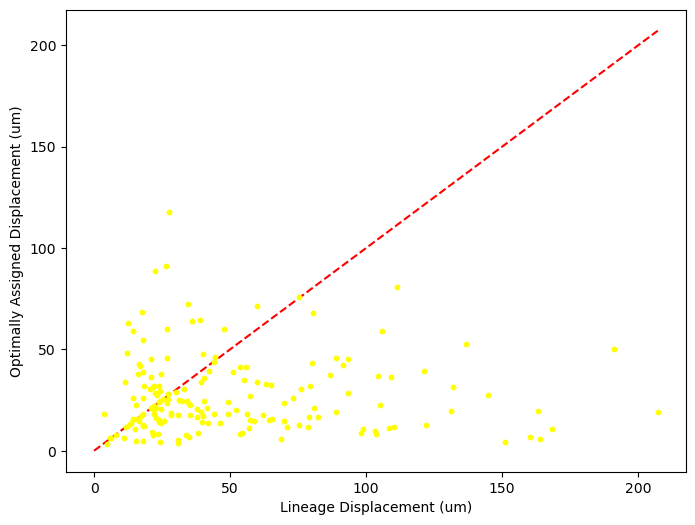

Optimal xyz assignment costs (norm=l2): Motility Cost = 4663.164612508643, Expression Cost = 711357.3407386612
number of optimally assigned displacements stayed the same: 14
Top 5 Terminal Nodes with Largest Decrease in Displacement Cost:
Terminal Node: ABpraappap, Lineage Parent: ABpraappa, Optimal Parent: ABarpappp, Displacement Difference: -187.9747
Terminal Node: ABarpppaaa, Lineage Parent: ABarpppaa, Optimal Parent: ABarpapap, Displacement Difference: -158.1151
Terminal Node: Caaapa, Lineage Parent: Caaap, Optimal Parent: Caaaa, Displacement Difference: -157.4943
Terminal Node: ABarpaapap, Lineage Parent: ABarpaapa, Optimal Parent: ABplaaaap, Displacement Difference: -153.6071
Terminal Node: MSpaaappp, Lineage Parent: MSpaaapp, Optimal Parent: ABplaaapp, Displacement Difference: -146.9195


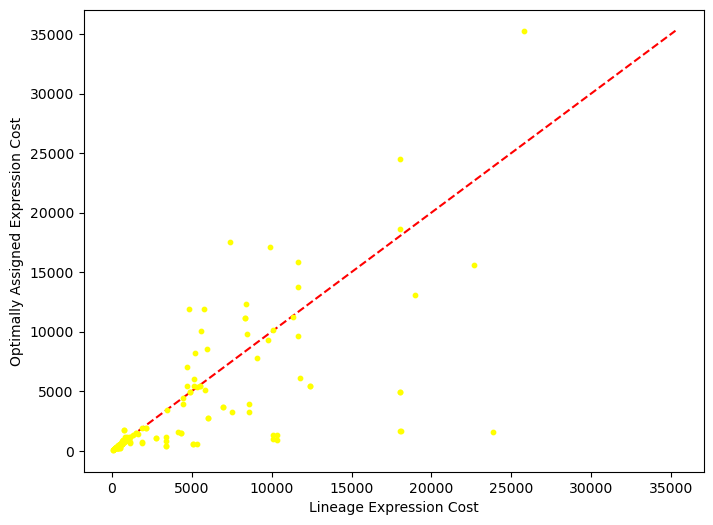

Optimal Expression assignment costs (norm=l2): Expression Cost = 519282.02104628965, Motility Cost = 21045.6848308273
number of optimally assigned displacements stayed the same: 61
Top 5 Terminal Nodes with Largest Decrease in Expression Cost:
Terminal Node: MSaaapapp, Lineage Parent: MSaaapap, Optimal Parent: ABplpappaa, Displacement Difference: -22323.1143
Terminal Node: ABarpaaaapp, Lineage Parent: ABarpaaaap, Optimal Parent: ABplppaaaa, Displacement Difference: -16440.7065
Terminal Node: ABalaapappp, Lineage Parent: ABalaapapp, Optimal Parent: ABalapappp, Displacement Difference: -16397.6017
Terminal Node: MSaaaapap, Lineage Parent: MSaaaapa, Optimal Parent: ABalpaapap, Displacement Difference: -13130.8462
Terminal Node: MSaaapaap, Lineage Parent: MSaaapaa, Optimal Parent: ABaraaapap, Displacement Difference: -13130.8462


Monte Carlo Simulation:   0%|          | 0/1000000 [00:00<?, ?it/s]

Computing random costs by 1st cousins shuffle:   0%|          | 0/100000 [00:00<?, ?it/s]

Computing random costs by 2nd cousins shuffle:   0%|          | 0/100000 [00:00<?, ?it/s]

Computing random costs by 3rd cousins shuffle:   0%|          | 0/100000 [00:00<?, ?it/s]

0.997 4757.366657453041
lineage costs: xyz, 8709.52616112023 exp, 660884.2052564214
bottom right corner: 21045.6848308273 519282.02104628965
top left corner: 4663.164612508643 711357.3407386612
monte carlo costs: xyz, 29340.43470492886 exp, 785127.719839719
monte carlo costs std: xyz, 962.3509496762001 exp, 11304.100158858708


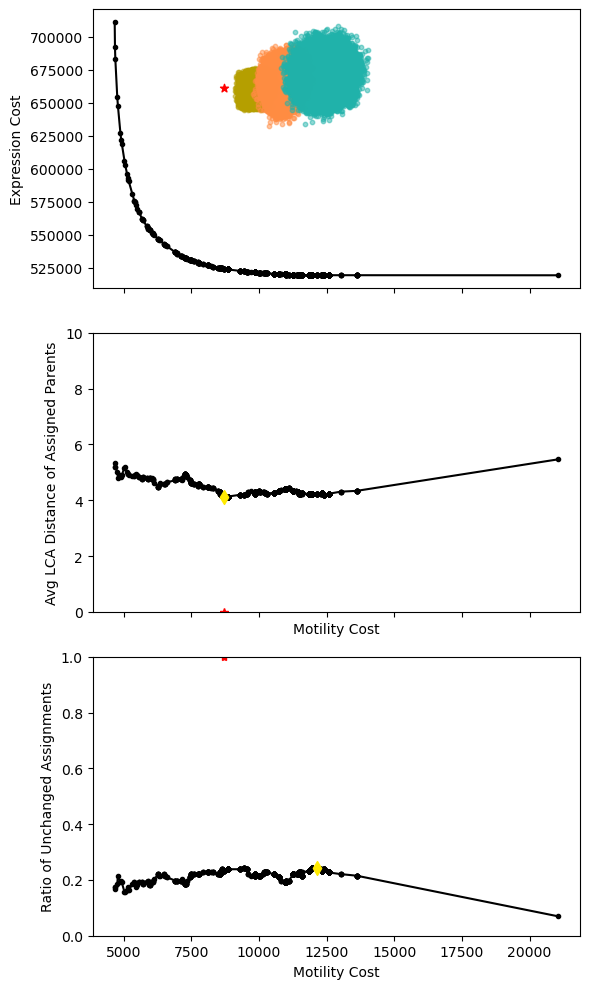

In [127]:
res = new_pf.pre_plot()

In [20]:
xyz_cost_mat, exp_cost_mat = new_pf.compute_cost_matrices()

100%|██████████| 197/197 [00:00<00:00, 581.72it/s]


In [23]:
cur_row_ind, cur_col_ind = linear_sum_assignment(xyz_cost_mat)

In [24]:
xyz_cost_mat[cur_row_ind, cur_col_ind].sum()

np.float64(5481.550463858858)

In [25]:
xyz_cost_mat[cur_row_ind, cur_row_ind].sum()

np.float64(10473.387782292444)

In [ ]:
monte_carlo_list, pareto_xyz_cost_list, pareto_exp_cost_list, lineage_xyz_cost, lineage_exp_cost = res

TypeError: cannot unpack non-iterable NoneType object

In [34]:
monte_carlo_xyz_cost = [item[0] for item in monte_carlo_list]
monte_carlo_exp_cost = [item[1] for item in monte_carlo_list]
monte_carlo_xyz_mean = np.mean(monte_carlo_xyz_cost)
monte_carlo_exp_mean = np.mean(monte_carlo_exp_cost)
monte_carlo_xyz_std = np.std(monte_carlo_xyz_cost)
monte_carlo_exp_std = np.std(monte_carlo_exp_cost)

print((monte_carlo_xyz_mean - lineage_xyz_cost) / monte_carlo_xyz_std, (monte_carlo_exp_mean - lineage_exp_cost) / monte_carlo_exp_std)
print((monte_carlo_xyz_mean - np.min(pareto_xyz_cost_list)) / monte_carlo_xyz_std, (monte_carlo_exp_mean - np.min(pareto_exp_cost_list)) / monte_carlo_exp_std)


43.730214517960704 50.18799286493368
49.61225039266454 56.22062423232257


100%|██████████| 248/248 [00:00<00:00, 267.58it/s]



Computing cost matrices with expression norm: L1


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


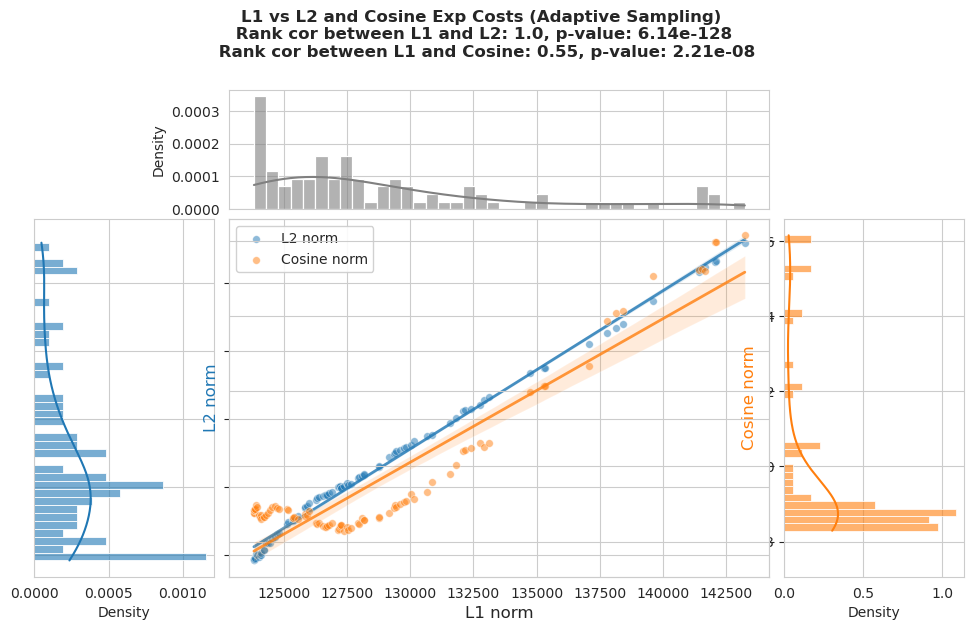

unique number of L1 cost values: 89
Computing cost matrices with expression norm: L2


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


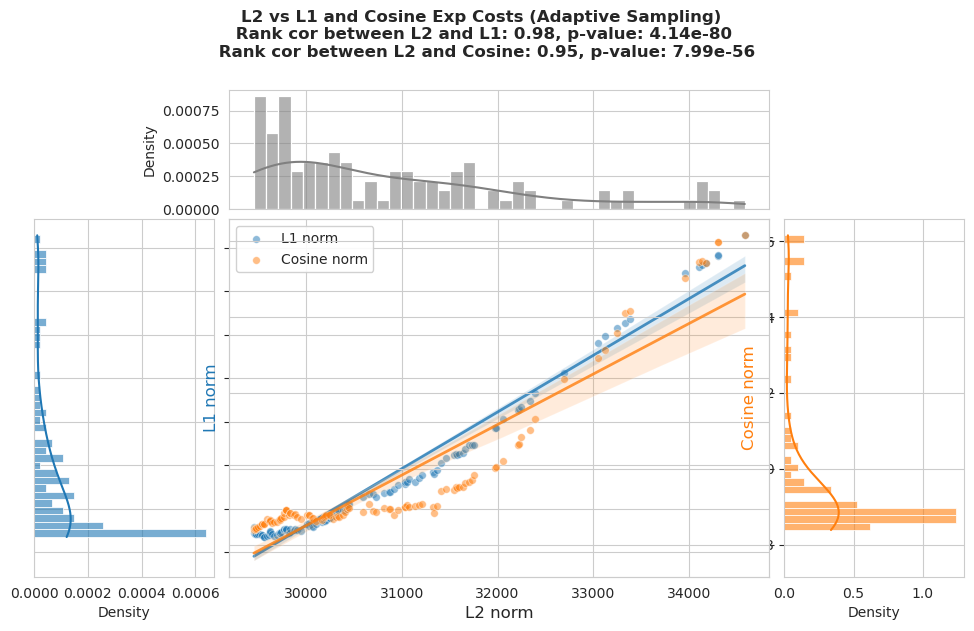

unique number of L2 cost values: 108
Computing cost matrices with expression norm: Cosine


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


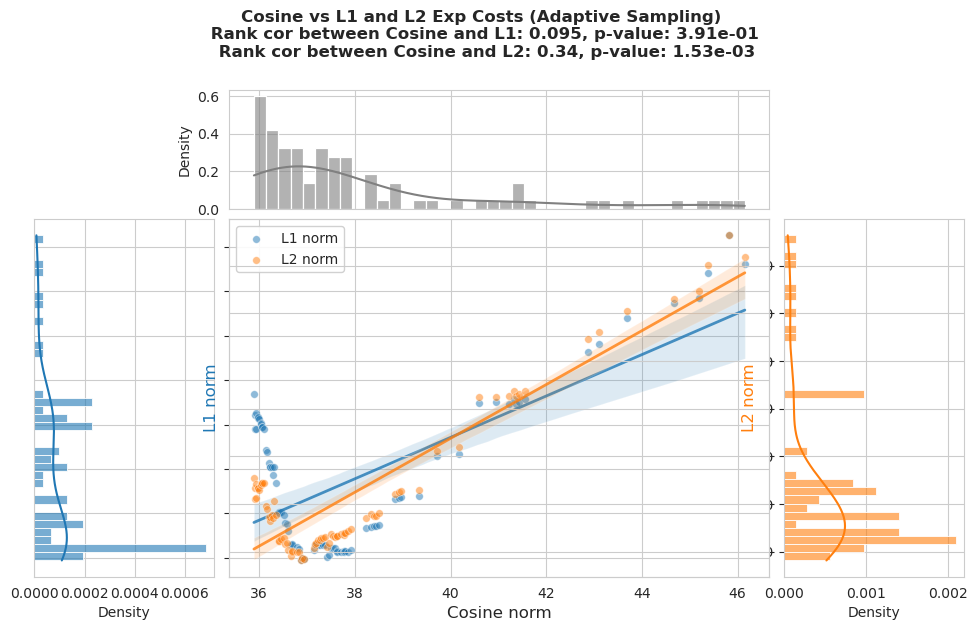

unique number of Cosine cost values: 84


In [45]:
res = new_pf.norm_comp_with_adaptive_sampling()

100%|██████████| 248/248 [00:00<00:00, 266.34it/s]



Computing cost matrices with expression norm: l1


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


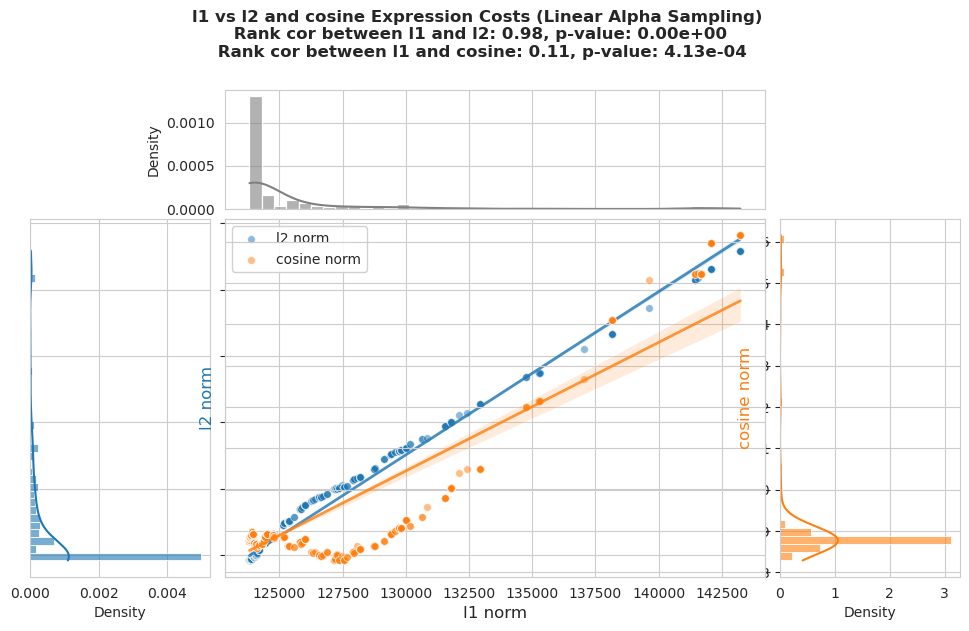

unique number of l1 cost values: 142
Computing cost matrices with expression norm: l2


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


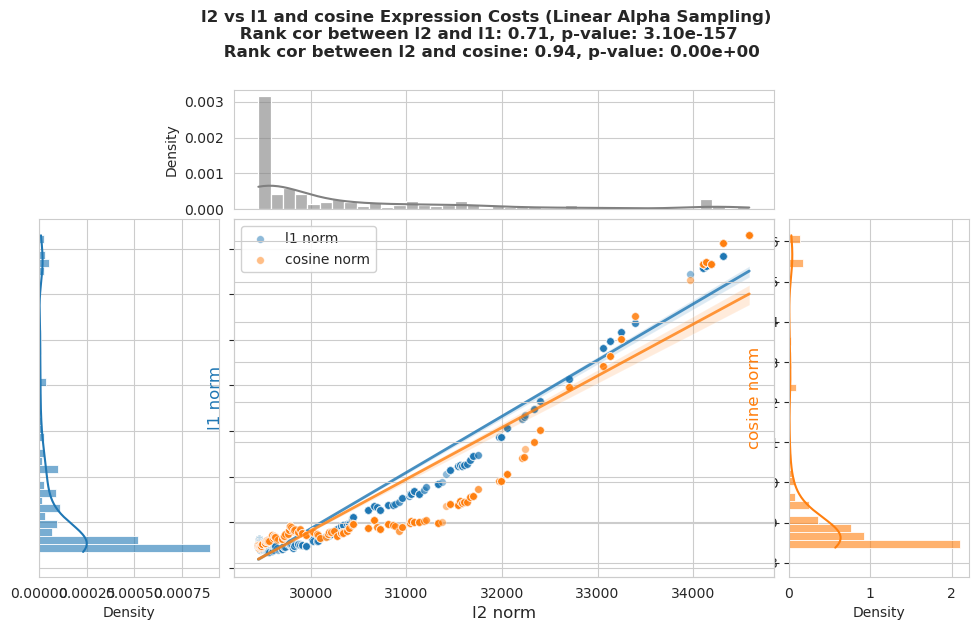

unique number of l2 cost values: 201
Computing cost matrices with expression norm: cosine


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


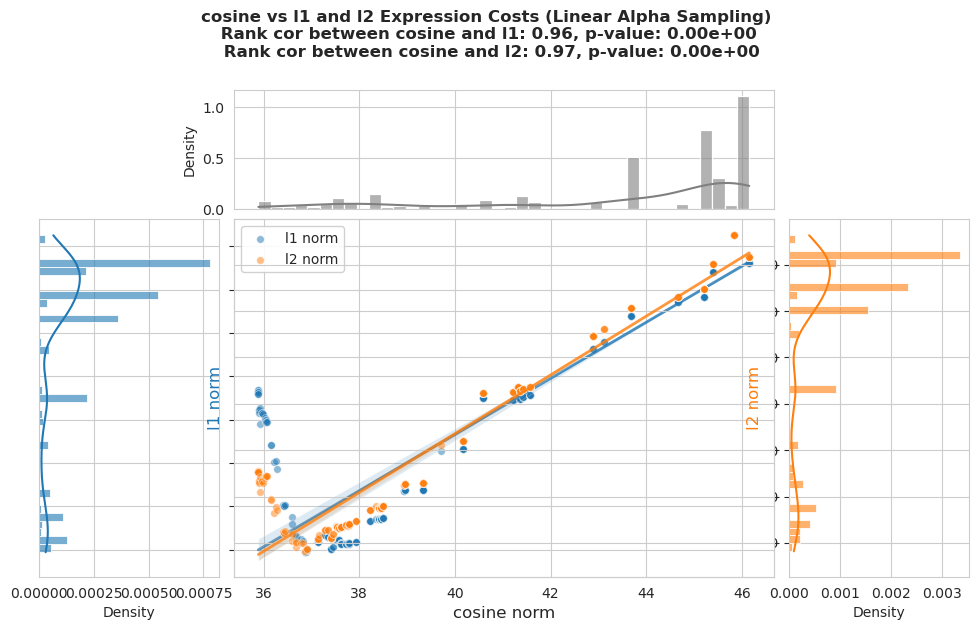

unique number of cosine cost values: 101


In [46]:
l2_cost_list, cosine_cost_list = new_pf.norm_comp()

In [ ]:
from scipy.spatial import KDTree

In [ ]:
kd_tree = KDTree(lineage_exp.T)


In [57]:
lineage_exp.sum()

cell
ABa        123.10
ABal       370.06
ABala      395.98
ABalaa     414.86
ABalaaa    710.05
            ...  
P2         317.11
P3         361.52
P4         289.33
Z2         302.14
Z3         318.65
Length: 1204, dtype: float64